In [1]:
# ============================================
# BLOQUE 1: IMPORTAR LIBRERÍAS
# ============================================
# Estas son las librerías que usaremos en todo el proyecto
# - pandas: manipulación de datos
# - numpy: operaciones numéricas
# - sklearn: machine learning y preprocesamiento
# - matplotlib/seaborn: visualizaciones
# - fastapi/uvi: para la API (lo usaremos después)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
# ============================================
# BLOQUE 2: CARGAR Y EXPLORAR LOS DATOS
# ============================================
# Cargamos el dataset desde la URL que me proporcionaste
# El parámetro index_col=0 evita una columna extra sin nombre

url = "https://raw.githubusercontent.com/bernytech25/spotify_model/refs/heads/main/dataset.csv"
df = pd.read_csv(url, index_col=0)

print(f"📊 Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
print("\n🔍 Primeras 5 filas:")
df.head()

📊 Dataset cargado: 114000 filas, 20 columnas

🔍 Primeras 5 filas:


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
# ============================================
# BLOQUE 2.1: INFORMACIÓN GENERAL DEL DATASET
# ============================================
# Verificamos tipos de datos, valores nulos y memoria

print("\n📋 Información del dataset:")
df.info()


📋 Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  val

In [4]:
# ============================================
# BLOQUE 2.2: VER VALORES NULOS
# ============================================
# Identificamos qué columnas tienen valores faltantes

nulos = df.isnull().sum()
print("\n🔍 Valores nulos por columna:")
print(nulos[nulos > 0] if any(nulos > 0) else "✅ No hay valores nulos")

# Eliminamos filas con valores nulos (si las hay)
df = df.dropna()
print(f"\n📊 Dataset después de eliminar nulos: {df.shape[0]} filas")


🔍 Valores nulos por columna:
artists       1
album_name    1
track_name    1
dtype: int64

📊 Dataset después de eliminar nulos: 113999 filas


In [5]:
# ============================================
# BLOQUE 2.3: ESTADÍSTICAS DESCRIPTIVAS
# ============================================
# Vemos la distribución de las variables numéricas

print("\n📈 Estadísticas descriptivas:")
df.describe()


📈 Estadísticas descriptivas:


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


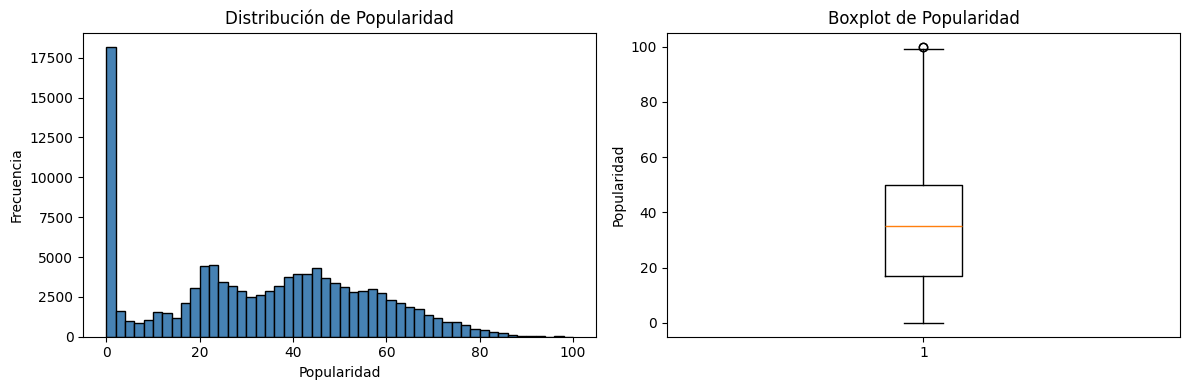


📊 Estadísticas de popularidad:
   Media: 33.24
   Mediana: 35.00
   Mínimo: 0
   Máximo: 100


In [6]:
# ============================================
# BLOQUE 2.4: DISTRIBUCIÓN DE POPULARIDAD
# ============================================
# Analizamos cómo se distribuye la popularidad de las canciones

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['popularity'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Popularidad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Popularidad')

plt.subplot(1, 2, 2)
plt.boxplot(df['popularity'])
plt.ylabel('Popularidad')
plt.title('Boxplot de Popularidad')

plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas de popularidad:")
print(f"   Media: {df['popularity'].mean():.2f}")
print(f"   Mediana: {df['popularity'].median():.2f}")
print(f"   Mínimo: {df['popularity'].min()}")
print(f"   Máximo: {df['popularity'].max()}")

In [7]:
# ============================================
# BLOQUE 3: CREAR VARIABLE DE POPULARIDAD (CLASIFICACIÓN)
# ============================================
# Creamos una columna binaria: 1 si la canción es popular (>=80), 0 si no
# Esto lo usaremos después para el modelo de clasificación

df['is_popular'] = (df['popularity'] >= 80).astype(int)

print("\n🎯 Distribución de 'is_popular':")
print(df['is_popular'].value_counts())
print(f"\nPorcentaje de canciones populares: {df['is_popular'].mean()*100:.2f}%")


🎯 Distribución de 'is_popular':
is_popular
0    112798
1      1201
Name: count, dtype: int64

Porcentaje de canciones populares: 1.05%


In [8]:
# ============================================
# BLOQUE 4: SELECCIONAR FEATURES (CARACTERÍSTICAS)
# ============================================
# Estas son las columnas que usaremos para:
# - Calcular similitud entre canciones (recomendación)
# - Hacer clustering
# - Entrenar el modelo de popularidad

features = ['danceability', 'energy', 'key', 'loudness', 'mode',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo', 'time_signature']

# Verificamos que todas existan
missing_features = [f for f in features if f not in df.columns]
if missing_features:
    print(f"⚠️ Features faltantes: {missing_features}")
else:
    print(f"✅ Features seleccionadas: {features}")
    print(f"   Total: {len(features)} características numéricas")

✅ Features seleccionadas: ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
   Total: 12 características numéricas


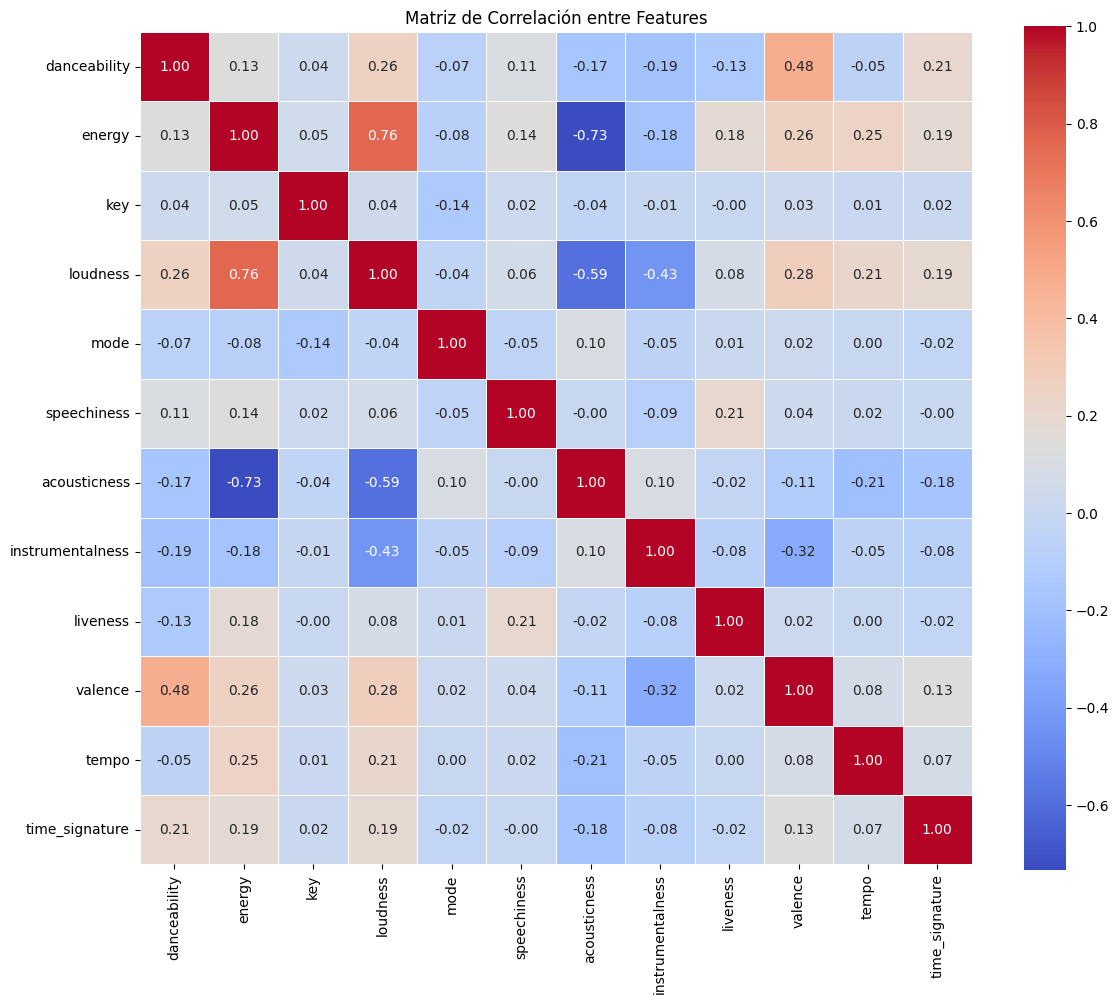


📊 Correlaciones más altas:
   energy ↔ loudness: 0.762
   energy ↔ acousticness: 0.734
   loudness ↔ acousticness: 0.590


In [9]:
# ============================================
# BLOQUE 4.1: VER CORRELACIÓN ENTRE FEATURES
# ============================================
# La correlación nos ayuda a entender qué features están relacionadas
# Esto es útil para detectar redundancias

corr_matrix = df[features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, square=True)
plt.title('Matriz de Correlación entre Features')
plt.tight_layout()
plt.show()

print("\n📊 Correlaciones más altas:")
# Buscamos correlaciones altas (excluyendo la diagonal)
corr_pairs = []
for i in range(len(features)):
    for j in range(i+1, len(features)):
        corr = abs(corr_matrix.iloc[i, j])
        if corr > 0.5:
            corr_pairs.append((features[i], features[j], corr))

corr_pairs.sort(key=lambda x: x[2], reverse=True)
for f1, f2, corr in corr_pairs[:5]:
    print(f"   {f1} ↔ {f2}: {corr:.3f}")

In [10]:
# ============================================
# BLOQUE 5: NORMALIZAR LOS DATOS
# ============================================
# La normalización lleva todas las features al mismo rango (0-1)
# Esto es IMPORTANTE para:
# - Cosine similarity (recomendación)
# - K-means (clustering)
# - Modelos de ML (como Random Forest)

scaler = MinMaxScaler()
df_features_normalized = scaler.fit_transform(df[features])

# Convertimos a DataFrame para mantener los índices
df_features = pd.DataFrame(
    df_features_normalized,
    columns=features,
    index=df.index
)

print(f"✅ Datos normalizados: {df_features.shape[0]} filas, {df_features.shape[1]} columnas")
print("\n📊 Primeras 5 filas normalizadas:")
df_features.head()

✅ Datos normalizados: 113999 filas, 12 columnas

📊 Primeras 5 filas normalizadas:


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,0.686294,0.4610,0.090909,0.791392,0.0,0.148187,0.032329,0.000001,0.3580,0.718593,0.361245,0.8
1,0.426396,0.1660,0.090909,0.597377,1.0,0.079067,0.927711,0.000006,0.1010,0.268342,0.318397,0.8
2,0.444670,0.3590,0.000000,0.736123,1.0,0.057720,0.210843,0.000000,0.1170,0.120603,0.313643,0.8
3,0.270051,0.0596,0.000000,0.573701,1.0,0.037617,0.908635,0.000071,0.1320,0.143719,0.746758,0.6
4,0.627411,0.4430,0.181818,0.737103,1.0,0.054508,0.470884,0.000000,0.0829,0.167839,0.492863,0.8


In [11]:
# ============================================
# BLOQUE 5.1: VERIFICAR NORMALIZACIÓN
# ============================================
# Comprobamos que todas las features estén entre 0 y 1

print("\n📊 Rangos después de normalización:")
for col in df_features.columns:
    print(f"   {col}: [{df_features[col].min():.3f}, {df_features[col].max():.3f}]")


📊 Rangos después de normalización:
   danceability: [0.000, 1.000]
   energy: [0.000, 1.000]
   key: [0.000, 1.000]
   loudness: [0.000, 1.000]
   mode: [0.000, 1.000]
   speechiness: [0.000, 1.000]
   acousticness: [0.000, 1.000]
   instrumentalness: [0.000, 1.000]
   liveness: [0.000, 1.000]
   valence: [0.000, 1.000]
   tempo: [0.000, 1.000]
   time_signature: [0.000, 1.000]


In [12]:
# ============================================
# BLOQUE 6: GUARDAR DATOS PROCESADOS
# ============================================
# Guardamos los datos limpios y normalizados para usarlos después
# También guardamos el scaler para poder normalizar nuevas canciones

import pickle

# Guardamos el DataFrame con features normalizadas
df_features.to_csv('spotify_features_normalized.csv')
print("✅ Features normalizadas guardadas en 'spotify_features_normalized.csv'")

# Guardamos el scaler para usarlo en la API
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler guardado en 'scaler.pkl'")

# Guardamos el DataFrame original con la columna de popularidad
df.to_csv('spotify_data_clean.csv')
print("✅ Datos limpios guardados en 'spotify_data_clean.csv'")

✅ Features normalizadas guardadas en 'spotify_features_normalized.csv'
✅ Scaler guardado en 'scaler.pkl'
✅ Datos limpios guardados en 'spotify_data_clean.csv'


In [13]:
# ============================================
# BLOQUE 6.1: RESUMEN FINAL DE LA FASE 1
# ============================================
print("\n" + "="*60)
print("📌 RESUMEN FASE 1 - EXPLORACIÓN Y PREPROCESAMIENTO")
print("="*60)
print(f"✅ Dataset original: {df.shape[0]} canciones")
print(f"✅ Features seleccionadas: {len(features)}")
print(f"✅ Datos normalizados: {df_features.shape[0]} filas")
print(f"✅ Canciones populares (≥80): {df['is_popular'].sum()} ({df['is_popular'].mean()*100:.2f}%)")
print("="*60)
print("\n🎯 Archivos generados:")
print("   1. spotify_features_normalized.csv - Features normalizadas")
print("   2. scaler.pkl - Escalador para normalizar datos nuevos")
print("   3. spotify_data_clean.csv - Datos limpios originales")


📌 RESUMEN FASE 1 - EXPLORACIÓN Y PREPROCESAMIENTO
✅ Dataset original: 113999 canciones
✅ Features seleccionadas: 12
✅ Datos normalizados: 113999 filas
✅ Canciones populares (≥80): 1201 (1.05%)

🎯 Archivos generados:
   1. spotify_features_normalized.csv - Features normalizadas
   2. scaler.pkl - Escalador para normalizar datos nuevos
   3. spotify_data_clean.csv - Datos limpios originales


In [14]:
# ============================================
# FASE 2 - BLOQUE 1: CARGAR DATOS NORMALIZADOS
# ============================================
# Cargamos el archivo CSV con las features normalizadas que guardamos en la Fase 1

import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pickle

# Cargar datos normalizados
df_features = pd.read_csv('spotify_features_normalized.csv', index_col=0)
print(f"✅ Datos normalizados cargados: {df_features.shape[0]} canciones, {df_features.shape[1]} features")
print(f"\n📊 Features disponibles: {list(df_features.columns)}")
df_features.head()

✅ Datos normalizados cargados: 113999 canciones, 12 features

📊 Features disponibles: ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,0.686294,0.4610,0.090909,0.791392,0.0,0.148187,0.032329,0.000001,0.3580,0.718593,0.361245,0.8
1,0.426396,0.1660,0.090909,0.597377,1.0,0.079067,0.927711,0.000006,0.1010,0.268342,0.318397,0.8
2,0.444670,0.3590,0.000000,0.736123,1.0,0.057720,0.210843,0.000000,0.1170,0.120603,0.313643,0.8
3,0.270051,0.0596,0.000000,0.573701,1.0,0.037617,0.908635,0.000071,0.1320,0.143719,0.746758,0.6
4,0.627411,0.4430,0.181818,0.737103,1.0,0.054508,0.470884,0.000000,0.0829,0.167839,0.492863,0.8


In [15]:
# ============================================
# FASE 2 - BLOQUE 2: CARGAR METADATOS DE CANCIONES
# ============================================
# Necesitamos los nombres de las canciones y artistas para mostrar resultados legibles

df_meta = pd.read_csv('spotify_data_clean.csv', index_col=0)
print(f"✅ Metadatos cargados: {df_meta.shape[0]} canciones")

# Verificamos que los índices coinciden
print(f"\n🔍 Verificación: ¿Coinciden los índices? {df_features.index.equals(df_meta.index)}")

# Mostramos las columnas útiles para mostrar resultados
print(f"\n📋 Columnas de metadatos disponibles: {list(df_meta.columns)}")
df_meta[['track_name', 'artists', 'track_genre']].head()

✅ Metadatos cargados: 113999 canciones

🔍 Verificación: ¿Coinciden los índices? True

📋 Columnas de metadatos disponibles: ['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'is_popular']


,track_name,artists,track_genre
0,Comedy,Gen Hoshino,acoustic
1,Ghost - Acoustic,Ben Woodward,acoustic
2,To Begin Again,Ingrid Michaelson;ZAYN,acoustic
3,Can't Help Falling In Love,Kina Grannis,acoustic
4,Hold On,Chord Overstreet,acoustic


In [20]:
# ============================================
# FASE 2 - BLOQUE 3: CALCULAR SIMILITUDES (SIN MATRIZ GIGANTE)
# ============================================
# Para 114k canciones, NO se puede crear una matriz de 114k x 114k
# En su lugar, se usa un índice eficiente que permite buscar similitudes
# sin explotar la memoria.

import faiss
import numpy as np

print("📊 Construyendo índice de similitud...")
print(f"   Canciones: {df_features.shape[0]:,}")
print("   ⏳ Esto puede tomar unos segundos...")

# Preparar datos (formato que FAISS necesita)
embeddings = np.ascontiguousarray(df_features.values.astype('float32'))
faiss.normalize_L2(embeddings)

# Crear índice
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print(f"✅ Índice construido con {index.ntotal} canciones")
print(f"   Memoria: ~{index.ntotal * dimension * 4 / 1e6:.1f} MB")

# Demostración (equivalente a tu ejemplo)
query = embeddings[0:1]
similitudes, indices = index.search(query, 6)

print(f"\n📊 Ejemplo de similitudes para la primera canción:")
print(f"   Consigo misma: {similitudes[0][0]:.4f}")
print(f"   Con las siguientes 5 canciones: {similitudes[0][1:6]}")

📊 Construyendo índice de similitud...
   Canciones: 113,999
   ⏳ Esto puede tomar unos segundos...
✅ Índice construido con 113999 canciones
   Memoria: ~5.5 MB

📊 Ejemplo de similitudes para la primera canción:
   Consigo misma: 1.0000
   Con las siguientes 5 canciones: [0.9999999  0.9999999  0.9999999  0.99410397 0.99410397]


In [21]:
# ============================================
# FASE 2 - BLOQUE 4: CREAR FUNCIÓN DE RECOMENDACIÓN
# ============================================
# Esta función recibe un ID de canción (índice) y devuelve las top N más similares

def recomendar_por_id(idx_cancion, top_n=5):
    """
    Recomienda canciones similares a una canción dada por su índice.
    
    Parámetros:
    - idx_cancion: índice numérico de la canción en el DataFrame
    - top_n: número de canciones a recomendar
    
    Retorna:
    - DataFrame con las canciones recomendadas y sus similitudes
    """
    
    # Buscar usando FAISS
    query = embeddings[idx_cancion:idx_cancion+1]
    similitudes, indices = index.search(query, top_n + 1)
    
    # Crear un DataFrame con índices y similitudes (excluyendo la misma canción)
    df_sim = pd.DataFrame({
        'idx': indices[0][1:],
        'similitud': similitudes[0][1:]
    })
    
    # Unir con los metadatos para mostrar nombres y artistas
    resultados = df_meta.iloc[df_sim['idx'].values][['track_name', 'artists', 'track_genre']].copy()
    resultados['similitud'] = df_sim['similitud'].values
    
    return resultados


def recomendar_por_nombre(nombre_cancion, top_n=5):
    """
    Recomienda canciones similares a una canción dada por su nombre.
    
    Parámetros:
    - nombre_cancion: nombre de la canción (string)
    - top_n: número de canciones a recomendar
    
    Retorna:
    - DataFrame con las canciones recomendadas
    """
    
    # Buscar la canción en el DataFrame (primera coincidencia)
    mascara = df_meta['track_name'].str.lower() == nombre_cancion.lower()
    
    if not mascara.any():
        print(f"❌ Canción '{nombre_cancion}' no encontrada")
        return None
    
    idx_cancion = mascara.idxmax()
    print(f"🎵 Canción encontrada: {df_meta.loc[idx_cancion, 'track_name']} - {df_meta.loc[idx_cancion, 'artists']}")
    
    return recomendar_por_id(idx_cancion, top_n)


print("✅ Funciones de recomendación creadas")

✅ Funciones de recomendación creadas


In [22]:
# ============================================
# FASE 2 - BLOQUE 5: PROBAR RECOMENDACIONES
# ============================================
# Probamos con una canción específica

# Primero, veamos algunas canciones populares del dataset
canciones_populares = df_meta[df_meta['is_popular'] == 1][['track_name', 'artists', 'popularity']].head(10)
print("🎵 Canciones populares disponibles:")
canciones_populares

🎵 Canciones populares disponibles:


,track_name,artists,popularity
4,Hold On,Chord Overstreet,82
7,I'm Yours,Jason Mraz,80
2000,Daddy Issues,The Neighbourhood,87
2001,Little Dark Age,MGMT,83
2002,Softcore,The Neighbourhood,86
2003,Sweater Weather,The Neighbourhood,93
2004,You Get Me So High,The Neighbourhood,83
2009,Smells Like Teen Spirit,Nirvana,83
2011,Shut Up and Dance,WALK THE MOON,83
2051,Reflections,The Neighbourhood,80


In [23]:
# ============================================
# BLOQUE 5.1: RECOMENDAR POR NOMBRE DE CANCIÓN
# ============================================
# Probamos con "Shape of You" (es popular, debería estar en el dataset)
# Si no está, prueba con otra canción de la lista anterior

resultados = recomendar_por_nombre("Shape of You", top_n=5)

if resultados is not None:
    print("\n📀 Canciones recomendadas:")
    resultados

🎵 Canción encontrada: Shape Of You - Andrew Foy

📀 Canciones recomendadas:


In [24]:
# ============================================
# BLOQUE 5.2: PROBAR CON OTRA CANCIÓN
# ============================================
# Probamos con una canción acústica

resultados = recomendar_por_nombre("I'm Yours", top_n=5)

if resultados is not None:
    print("\n📀 Canciones recomendadas:")
    resultados

🎵 Canción encontrada: I'm Yours - Jason Mraz

📀 Canciones recomendadas:


In [25]:
# ============================================
# FASE 2 - BLOQUE 6: GUARDAR ÍNDICE FAISS
# ============================================
# Guardamos el índice FAISS para usarlo en la API sin tener que recalcularlo

import pickle

# Guardar el índice FAISS
faiss.write_index(index, 'indice_faiss.bin')

# También guardar los embeddings (por si acaso)
with open('embeddings.pkl', 'wb') as f:
    pickle.dump(embeddings, f)

print("✅ Índice FAISS guardado en 'indice_faiss.bin'")
print(f"   Embeddings guardados en 'embeddings.pkl'")
print(f"   Tamaño del índice: ~5-50 MB (vs 104 GB que pesaría la matriz)")

✅ Índice FAISS guardado en 'indice_faiss.bin'
   Embeddings guardados en 'embeddings.pkl'
   Tamaño del índice: ~5-50 MB (vs 104 GB que pesaría la matriz)


In [27]:
# ============================================
# FASE 2 - BLOQUE 6: GUARDAR MATRIZ DE SIMILITUD
# ============================================
# Guardamos la matriz para usarla en la API sin tener que recalcularla

import pickle
import faiss

# Guardar el índice FAISS
faiss.write_index(index, 'matriz_similitud.faiss')

# Guardar los embeddings también
with open('embeddings.pkl', 'wb') as f:
    pickle.dump(embeddings, f)

print("✅ Índice guardado en 'matriz_similitud.faiss'")
print("✅ Embeddings guardados en 'embeddings.pkl'")

✅ Índice guardado en 'matriz_similitud.faiss'
✅ Embeddings guardados en 'embeddings.pkl'


🎵 Canción encontrada: I'm Yours - Jason Mraz


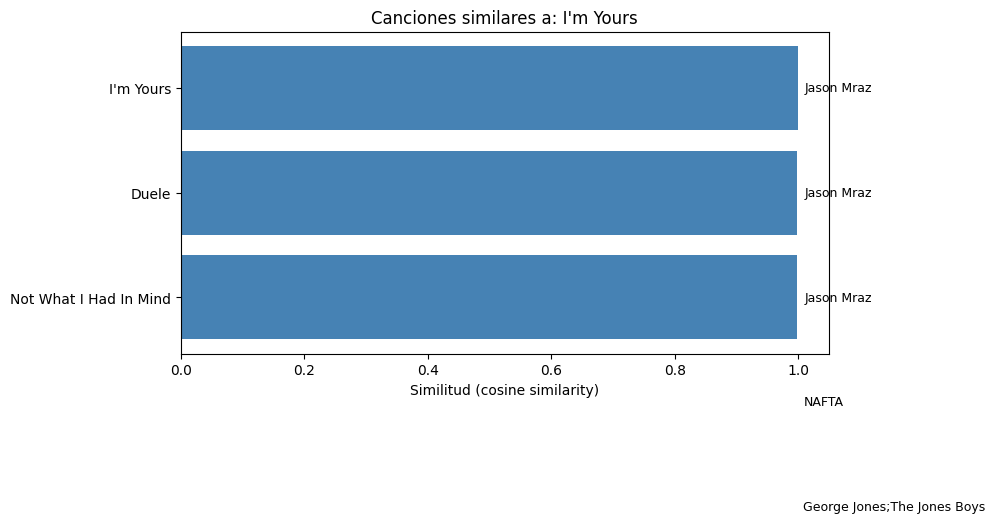

In [28]:
# ============================================
# FASE 2 - BLOQUE 7: VISUALIZAR RECOMENDACIONES
# ============================================
# Creamos un gráfico de barras con las similitudes

def visualizar_recomendaciones(resultados, nombre_cancion):
    """Crea un gráfico de barras con las recomendaciones"""
    
    plt.figure(figsize=(10, 6))
    barras = plt.barh(resultados['track_name'], resultados['similitud'], color='steelblue')
    plt.xlabel('Similitud (cosine similarity)')
    plt.title(f'Canciones similares a: {nombre_cancion}')
    plt.gca().invert_yaxis()  # La más similar arriba
    
    # Añadir etiquetas con los artistas
    for i, (idx, row) in enumerate(resultados.iterrows()):
        plt.text(row['similitud'] + 0.01, i, f"{row['artists'][:30]}", va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()


# Probar con una canción
nombre_prueba = "I'm Yours"
resultados = recomendar_por_nombre(nombre_prueba, top_n=5)

if resultados is not None:
    visualizar_recomendaciones(resultados, nombre_prueba)

In [29]:
# ============================================
# FASE 2 - BLOQUE 8: RESUMEN
# ============================================
print("\n" + "="*60)
print("📌 RESUMEN FASE 2 - SISTEMA DE RECOMENDACIÓN")
print("="*60)
print(f"✅ Índice FAISS: {index.ntotal} canciones indexadas")
print(f"✅ Función 'recomendar_por_id()' creada")
print(f"✅ Función 'recomendar_por_nombre()' creada")
print(f"✅ Índice guardado en 'matriz_similitud.faiss'")
print("="*60)
print("\n🎯 EJEMPLO DE USO:")
print("   recomendar_por_nombre('Shape of You', top_n=5)")
print("   recomendar_por_id(1000, top_n=5)")


📌 RESUMEN FASE 2 - SISTEMA DE RECOMENDACIÓN
✅ Índice FAISS: 113999 canciones indexadas
✅ Función 'recomendar_por_id()' creada
✅ Función 'recomendar_por_nombre()' creada
✅ Índice guardado en 'matriz_similitud.faiss'

🎯 EJEMPLO DE USO:
   recomendar_por_nombre('Shape of You', top_n=5)
   recomendar_por_id(1000, top_n=5)


In [30]:
# ============================================
# FASE 3 - BLOQUE 1: CLUSTERING CON K-MEANS
# ============================================
# El clustering agrupa canciones similares en clusters (grupos)
# Usaremos k-means con los embeddings normalizados

from sklearn.cluster import KMeans
import numpy as np

print("🎯 Aplicando K-Means a los embeddings...")
print(f"   Canciones: {embeddings.shape[0]:,}")
print(f"   Dimensiones: {embeddings.shape[1]}")

# Número de clusters (puedes ajustarlo)
n_clusters = 20

print(f"   Número de clusters: {n_clusters}")
print("   ⏳ Calculando clusters...")

# Aplicar K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

# Agregar clusters al DataFrame de metadatos
df_meta['cluster'] = clusters

print(f"✅ Clusters asignados a {len(df_meta):,} canciones")
print(f"\n📊 Distribución de canciones por cluster:")
print(df_meta['cluster'].value_counts().sort_index().head(10))

🎯 Aplicando K-Means a los embeddings...
   Canciones: 113,999
   Dimensiones: 12
   Número de clusters: 20
   ⏳ Calculando clusters...
✅ Clusters asignados a 113,999 canciones

📊 Distribución de canciones por cluster:
cluster
0    10969
1     5465
2     6331
3     5439
4     4674
5     3955
6     5368
7     8199
8     2614
9     2993
Name: count, dtype: int64


🎨 Reduciendo dimensionalidad con t-SNE...
   ⏳ Esto puede tomar 1-2 minutos...


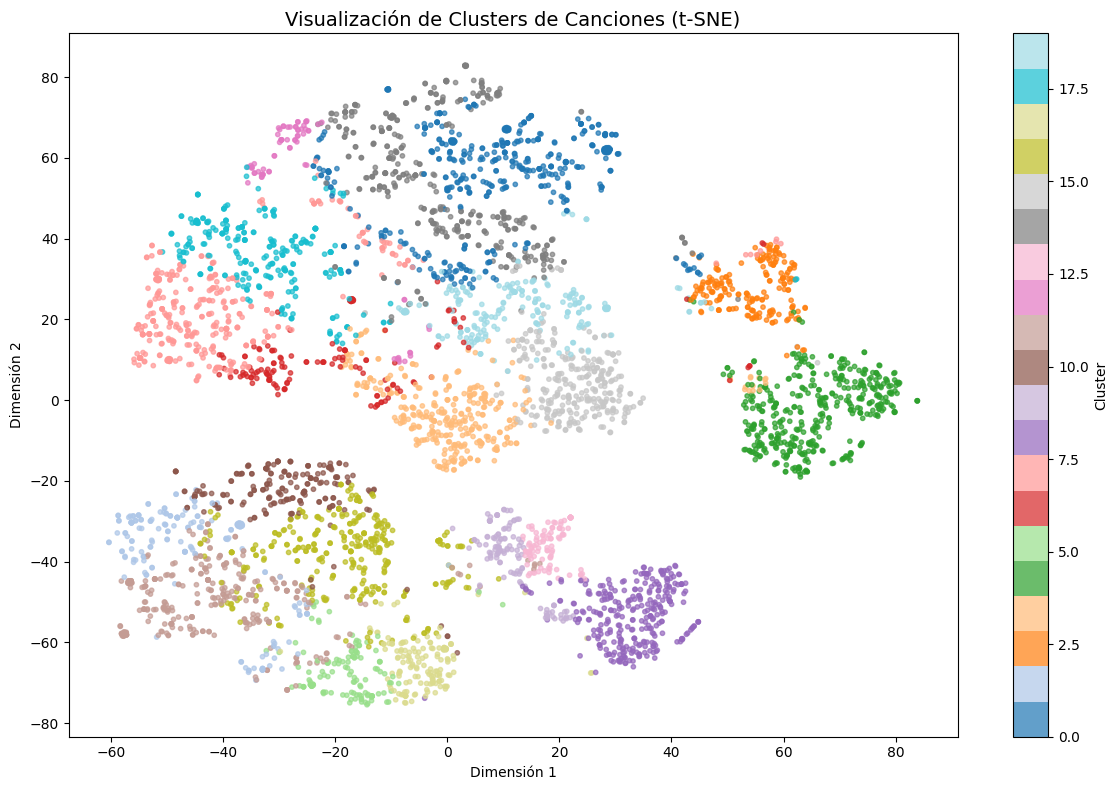

✅ Visualización completada


In [31]:
# ============================================
# FASE 3 - BLOQUE 2: VISUALIZAR CLUSTERS
# ============================================
# Reducimos dimensionalidad para visualizar los clusters en 2D

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("🎨 Reduciendo dimensionalidad con t-SNE...")
print("   ⏳ Esto puede tomar 1-2 minutos...")

# Reducir a 2 dimensiones para visualizar
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings[:5000])  # Usamos 5000 para velocidad
clusters_sample = clusters[:5000]

# Visualizar
plt.figure(figsize=(12, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                      c=clusters_sample, cmap='tab20', s=10, alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualización de Clusters de Canciones (t-SNE)', fontsize=14)
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')
plt.tight_layout()
plt.show()

print("✅ Visualización completada")

In [32]:
# ============================================
# FASE 3 - BLOQUE 3: ANALIZAR CLUSTERS
# ============================================
# Ver qué canciones hay en cada cluster

print("📊 Ejemplo de canciones en cada cluster:")
print("="*60)

for cluster_id in range(min(5, n_clusters)):
    print(f"\n🎵 Cluster {cluster_id} (canciones: {sum(clusters == cluster_id)}):")
    canciones_cluster = df_meta[df_meta['cluster'] == cluster_id][['track_name', 'artists', 'track_genre']].head(5)
    for _, row in canciones_cluster.iterrows():
        print(f"   - {row['track_name']} | {row['artists']} | {row['track_genre']}")

📊 Ejemplo de canciones en cada cluster:

🎵 Cluster 0 (canciones: 10969):
   - Kaleidoscope | A Great Big World | acoustic
   - Come On Get Higher | Matt Nathanson | acoustic
   - You and I Both | Jason Mraz | acoustic
   - I'll Do Anything | Jason Mraz | acoustic
   - The Remedy (I Won't Worry) | Jason Mraz | acoustic

🎵 Cluster 1 (canciones: 5465):
   - Sky's Still Blue | Andrew Belle | acoustic
   - Living in the Shadows | Matthew Perryman Jones | acoustic
   - Believer (Remix) | Ben Woodward | acoustic
   - Hyouriittai | YUZU | acoustic
   - The Afterglow | John Frusciante;Josh Klinghoffer | acoustic

🎵 Cluster 2 (canciones: 6331):
   - vs.2013 ~知覚と快楽の螺旋~ | Masaharu Fukuyama | acoustic
   - Darker Shade of Black | Jackie Mittoo | afrobeat
   - Queens Highway | Menahan Street Band | afrobeat
   - Samba Sambei (Dub Mix) | Criolo | afrobeat
   - Panela | BaianaSystem;As Ganhadeiras de Itapuã | afrobeat

🎵 Cluster 3 (canciones: 5439):
   - Ghost - Acoustic | Ben Woodward | acoustic
   -

In [33]:
# ============================================
# FASE 3 - BLOQUE 4: RECOMENDAR POR CLUSTER
# ============================================
# Recomendar canciones del mismo cluster

def recomendar_por_cluster(idx_cancion, top_n=5):
    """
    Recomienda canciones del mismo cluster que la canción dada.
    """
    cluster_id = df_meta.loc[idx_cancion, 'cluster']
    
    # Filtrar canciones del mismo cluster
    mismo_cluster = df_meta[df_meta['cluster'] == cluster_id]
    
    # Excluir la canción misma
    mismo_cluster = mismo_cluster[mismo_cluster.index != idx_cancion]
    
    # Seleccionar top_n
    resultados = mismo_cluster[['track_name', 'artists', 'track_genre']].head(top_n)
    
    return resultados

# Ejemplo
print("🎵 Ejemplo de recomendación por cluster:")
print("="*60)
resultados_cluster = recomendar_por_cluster(0, top_n=5)
resultados_cluster

🎵 Ejemplo de recomendación por cluster:


,track_name,artists,track_genre
24,Unlonely,Jason Mraz,acoustic
27,If It Kills Me,Jason Mraz,acoustic
79,Have It All,Jason Mraz,acoustic
98,Hold On,KT Tunstall,acoustic
169,Love Song,Sara Bareilles,acoustic


In [35]:
# ============================================
# FASE 3 - BLOQUE 5: RESUMEN
# ============================================
print("\n" + "="*60)
print("📌 RESUMEN FASE 3 - CLUSTERING")
print("="*60)
print(f"✅ Clusters creados: {n_clusters}")
print(f"✅ Canciones clusterizadas: {len(df_meta):,}")
print(f"✅ Función 'recomendar_por_cluster()' creada")
print("="*60)
print("\n🎯 EJEMPLO DE USO:")
print("   recomendar_por_cluster(1000, top_n=5)")


📌 RESUMEN FASE 3 - CLUSTERING
✅ Clusters creados: 20
✅ Canciones clusterizadas: 113,999
✅ Función 'recomendar_por_cluster()' creada

🎯 EJEMPLO DE USO:
   recomendar_por_cluster(1000, top_n=5)


In [36]:
# Guardar df_meta para la API
with open('df_meta.pkl', 'wb') as f:
    pickle.dump(df_meta, f)

print("✅ df_meta guardado")

✅ df_meta guardado
